# Customer Segmentation Analysis

## 🎯 Objective
The goal of this notebook is to segment customers into meaningful groups based on churn risk, tenure, revenue contribution, and engagement level. These segments will help the business design targeted retention and marketing strategies.

In [2]:
# Load cleaned dataset for analysis
import pandas as pd

df = pd.read_csv("E:/Customer Churn Analysis/data/processed/telco_churn_cleaned.csv")

c:\Users\mahdi\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\mahdi\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Segmentation Strategy

Customers are segmented based on:

- Contract type (commitment level)
- Tenure (customer lifecycle stage)
- Monthly charges (customer value)
- Churn risk score (behavioral risk)

In [3]:
# Construct a rule‐based risk score using behavioural and service factors
# Start with zero risk and increment based on each condition
df['risk_score'] = 0

# Customers on month‐to‐month contracts have a higher risk due to low commitment
df.loc[df['contract'] == 'Month-to-month', 'risk_score'] += 2

# Customers in the early stages of their lifecycle (≤ 12 months) are more likely to churn
df.loc[df['tenure'] <= 12, 'risk_score'] += 2

# Electronic check indicates manual payments, which correlate with lower engagement
df.loc[df['paymentmethod'] == 'Electronic check', 'risk_score'] += 1

# Lack of Tech Support or Online Security services increases churn risk
df.loc[df['techsupport'] == 'No', 'risk_score'] += 1
df.loc[df['onlinesecurity'] == 'No', 'risk_score'] += 1

# Customers paying more than the median monthly charge may be price sensitive
df.loc[df['monthlycharges'] > df['monthlycharges'].median(), 'risk_score'] += 1

# Map the numerical risk score to categorical levels
def assign_risk_level(score):
    if score >= 6:
        return 'High Risk'
    elif score >= 3:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['risk_level'] = df['risk_score'].apply(assign_risk_level)

# Preview the distribution of customers across risk levels
df['risk_level'].value_counts()

risk_level
Low Risk       2550
Medium Risk    2254
High Risk      2239
Name: count, dtype: int64

In [4]:
# Create tenure groups to capture customer lifecycle stages

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["New (0-1y)", "Growing (1-2y)", "Mature (2-4y)", "Loyal (4y+)"]
)

df.groupby("tenure_group")["churn_flag"].mean()

tenure_group
New (0-1y)        0.476782
Growing (1-2y)    0.287109
Mature (2-4y)     0.203890
Loyal (4y+)       0.095132
Name: churn_flag, dtype: float64

In [5]:
# Segment customers into value tiers based on monthly charges (terciles)

df["value_segment"] = pd.qcut(
    df["monthlycharges"],
    q=3,
    labels=["Low Value", "Mid Value", "High Value"]
)
df.groupby("value_segment")["churn_flag"].mean()

value_segment
Low Value     0.158656
Mid Value     0.296802
High Value    0.340861
Name: churn_flag, dtype: float64

In [6]:
# Combine risk level, tenure group and value segment to build a multi-dimensional segmentation
# Calculate key metrics: number of customers, churn rate and average revenue (total charges)
segment_summary = df.groupby([
    'risk_level',
    'tenure_group',
    'value_segment'
]).agg(
    customer_count=('customerid', 'count'),
    churn_rate=('churn_flag', 'mean'),
    avg_revenue=('totalcharges', 'mean')
).reset_index()

# Convert churn rate to percentage for easier interpretation
segment_summary['churn_rate'] = segment_summary['churn_rate'] * 100

# Sort segments by churn rate descending to highlight risky groups
segment_summary_sorted = segment_summary.sort_values('churn_rate', ascending=False)

segment_summary_sorted.head(10)

,risk_level,tenure_group,value_segment,customer_count,churn_rate,avg_revenue
2,High Risk,New (0-1y),High Value,363,74.104683,534.680579
22,Medium Risk,New (0-1y),High Value,14,64.285714,765.596429
3,High Risk,Growing (1-2y),Mid Value,59,62.711864,1354.553390
1,High Risk,New (0-1y),Mid Value,708,60.875706,309.898729
4,High Risk,Growing (1-2y),High Value,110,59.090909,1694.113636
6,High Risk,Mature (2-4y),High Value,145,55.862069,3327.017586
8,High Risk,Loyal (4y+),High Value,64,51.562500,5683.661719
25,Medium Risk,Growing (1-2y),High Value,171,48.538012,1747.206725
5,High Risk,Mature (2-4y),Mid Value,44,43.181818,2536.113636
7,High Risk,Loyal (4y+),Mid Value,10,40.000000,4294.520000


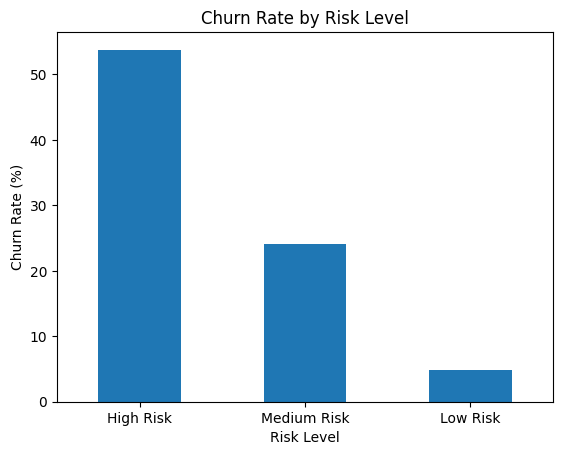

In [8]:
# Visualise churn rate by risk level

import matplotlib.pyplot as plt
risk_churn = df.groupby('risk_level')['churn_flag'].mean() * 100

plt.figure()
risk_churn.sort_values(ascending=False).plot(kind='bar')
plt.title('Churn Rate by Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [10]:
# Create aggregated pivot table (fix duplicate issue)

pivot_risk_value = segment_summary.pivot_table(
    index="risk_level",
    columns="value_segment",
    values="churn_rate",
    aggfunc="mean"   # مهم: اگر duplicate باشد میانگین می‌گیرد
)

pivot_risk_value

value_segment,Low Value,Mid Value,High Value
risk_level,,,
High Risk,36.005435,51.692347,60.155040
Low Risk,1.564019,4.826818,14.273116
Medium Risk,15.274821,21.542128,41.859029


<Figure size 800x500 with 0 Axes>

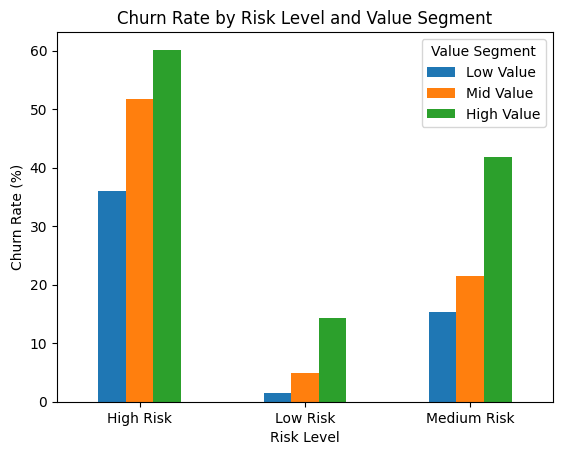

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

pivot_risk_value.plot(kind="bar")

plt.title("Churn Rate by Risk Level and Value Segment")
plt.xlabel("Risk Level")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Value Segment")

plt.show()

## 📌 Conclusion

The customer segmentation analysis shows that churn is primarily driven by behavioral and value-based factors rather than demographics.

High-risk customers—particularly those who are **new (≤ 1 year)** and **high value (top tercile of monthly charges)**—exhibit the highest churn rates, representing a critical **revenue leakage segment** for the business.

In contrast, long-tenure and low-risk customers contribute significantly to stable revenue with minimal churn risk.

---

## 🧠 Key Business Insight

Churn is highly concentrated in early lifecycle, high-value customers, indicating a gap in onboarding, engagement, and perceived value delivery during the first months of the customer journey.

---

## 🎯 Business Recommendations

To reduce churn and protect revenue, the company should:

- Focus on **early-stage customer retention strategies**
- Prioritize **high-value customers in their first 12 months**
- Encourage **long-term contract adoption**
- Promote **automated payment methods**
- Bundle **Tech Support and Online Security services**
- Improve overall **customer onboarding experience**

---

## 🚀 Executive Summary

A significant portion of revenue risk is concentrated among newly acquired high-value customers, making early engagement and retention strategies the most impactful lever for reducing churn.